# Extract Suitable Videos from this bunch of noisy ones

Problems:

Some of the videos
1. aren't about real cats (pictures, screens, dogs, text, etc.)
2. have more than one cat on them
3. are suitable, but the cat is silent (do we keep that?) 


chosen_videos = []
For every video
    segments <- split_video_into_segments(video)

    for segment in segments:

        detected_cats <- detect_cats(segment) # with YOLOv11?

        if len(detected_cats) == 0:
            discard
        elif len(detected_cats) == 1
            detected_cat = keep_it
        elif: len(detected_cats) > 1: # this logic for now
            discard

        if bbox_size(detected_cat) < 10%:
            discard
        else:
            save_video(segment, f"{video_name}_{segment_id}")

            chosen_videos.append({
                "video_name": ...,
                "segment_id": ...,
                "start_sec_video": ..., # for reference to video
                "end_sec_video:: ...,
            })
        
        

        

1. The "Scene" Upgrade

Instead of arbitrary segments (e.g., every 5 seconds), use Scene Detection. A hard cut in a YouTube video (from a cat to a person talking) will ruin your temporal model's "memory."

    Tool: PySceneDetect. It splits the video only when the camera angle actually changes.

2. The "Stability" Check

Instead of discarding a segment if one frame has two cats, use a Rolling Average or Majority Vote.

    Logic: If a segment is 60 frames long and YOLO sees 1 cat in 55 frames but 2 cats in 5 frames (maybe a tail was misidentified), keep it.

3. The Bounding Box "Buffer"

Don't just check the size; check the location. If the cat is at the very edge of the frame, half of its body language (the tail or ears) might be cut off, which is vital for emotion detection.

In [1]:
import os
import cv2
from ultralytics import YOLO
from tqdm import tqdm
import numpy as np

In [2]:
# Constants
MODEL_PATH = "yolo11m.pt"  # Nano version is fast and plenty for cat detection
CAT_CLASS_ID = 15          # COCO index for 'cat'
MIN_CONFIDENCE = 0.5       # Confidence threshold for detection
MIN_BBOX_AREA = 0.10       # 10% of total frame area
FRAME_SAMPLE_RATE = 24     # Check 1 frame every X frames

In [3]:
# Load model ONCE outside the function
model = YOLO(MODEL_PATH)

## Checking whether there is a cat on a video

In [6]:
def is_valid_cat_segment(video_path):
    cap = cv2.VideoCapture(video_path)
    
    stats = {
        "total_sampled": 0,
        "one_cat_count": 0,
        "multi_cat_count": 0,
        "zero_cat_count": 0,
        "small_cat_count": 0,
        "avg_area": [],
        "avg_conf": []
    }
    
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        if frame_idx % FRAME_SAMPLE_RATE == 0:
            stats["total_sampled"] += 1
            results = model(frame, verbose=False)[0]
            cats = [b for b in results.boxes if int(b.cls) == CAT_CLASS_ID and b.conf > MIN_CONFIDENCE]
            
            # --- Explainability Logic ---
            num_cats = len(cats)
            if num_cats == 0:
                stats["zero_cat_count"] += 1
            elif num_cats > 1:
                stats["multi_cat_count"] += 1
            else:
                # Exactly one cat found
                _, _, w, h = cats[0].xywhn[0].tolist()
                area = w * h
                stats["avg_area"].append(area)
                stats["avg_conf"].append(float(cats[0].conf))
                
                if area >= MIN_BBOX_AREA:
                    stats["one_cat_count"] += 1
                else:
                    stats["small_cat_count"] += 1
        
        frame_idx += 1
    cap.release()

    # --- Decision Logic with Reporting ---
    if stats["total_sampled"] == 0:
        return False, "Empty or unreadable video", stats

    success_rate = stats["one_cat_count"] / stats["total_sampled"]
    
    # Summary Metrics
    stats["final_score"] = round(success_rate, 2)
    stats["mean_area"] = round(np.mean(stats["avg_area"]), 4) if stats["avg_area"] else 0
    
    if success_rate > 0.8:
        return True, "Passed", stats
    
    # Determine the primary reason for failure
    if stats["zero_cat_count"] > (stats["total_sampled"] / 2):
        reason = "Subject missing (No cats detected in >50% of frames)"
    elif stats["multi_cat_count"] > (stats["total_sampled"] / 3):
        reason = "Multiple subjects (Crowded scene)"
    elif stats["small_cat_count"] > (stats["total_sampled"] / 2):
        reason = "Subject too small (Resolution/Distance issue)"
    else:
        reason = f"Temporal inconsistency (Only {int(success_rate*100)}% valid frames)"

    return False, reason, stats

In [7]:
sample_cat_video = "downloads/VideoDataUnbalanced/Watch MeMe Meow.mp4"

In [8]:
result = is_valid_cat_segment(sample_cat_video)
result[0]

False

In [7]:
def debug_realtime(video_path):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    print("Press 'q' to stop the video.")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, verbose=False)[0]
        cats = [b for b in results.boxes if int(b.cls) == CAT_CLASS_ID]
        
        status_text = "REJECTED: No Cat Found"
        color = (0, 0, 255) # Red

        if len(cats) > 1:
            status_text = f"REJECTED: Multi-cat ({len(cats)})"
            color = (0, 165, 255) # Orange
        
        for cat in cats:
            x1, y1, x2, y2 = map(int, cat.xyxy[0])
            conf = float(cat.conf)
            _, _, w_norm, h_norm = cat.xywhn[0].tolist()
            area = w_norm * h_norm
            
            passes_conf = conf >= MIN_CONFIDENCE
            passes_area = area >= MIN_BBOX_AREA
            
            # If it's a single cat and passes rules
            if len(cats) == 1:
                if passes_conf and passes_area:
                    status_text = "ACCEPTED"
                    color = (0, 255, 0) # Green
                else:
                    status_text = f"REJECTED: Conf:{conf:.2f} Area:{area:.2f}"
                    color = (0, 165, 255) # Orange

            # Draw UI
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
            cv2.putText(frame, f"C:{conf:.2f} A:{area:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Draw Global Status
        cv2.putText(frame, status_text, (30, 40), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        
        # SHOW THE FRAME
        cv2.imshow("Cat Emotion Data Cleaning Debugger", frame)

        # Press 'q' to quit or wait 1ms between frames
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    # A little trick for macOS to actually close the window
    for i in range(1, 5):
        cv2.waitKey(1)

In [8]:
debug_realtime(sample_cat_video)

Press 'q' to stop the video.


Think of basic detection like a person who forgets everything the moment they blink. If a cat's tail covers its face for one frame, the detector says, "No cat here!" A tracker, like BoT-SORT, adds "memory" **(a Kalman Filter)**. It predicts where the cat should be based on its previous speed and direction, even if the AI is temporarily unsure.

How Tracking Changes Your Logic

Instead of checking "Is there a cat in this frame?", we now check: "Is there a consistent Track ID that lasts for most of the video?"

    Identity Persistence: If a cat is detected as ID: 1, and the AI misses 3 frames, the tracker will keep ID: 1 alive.

    Noise Filtering: If a random pillow is mistaken for a cat for 2 frames, it gets a new ID (e.g., ID: 2). Since ID: 2 only exists for a split second, we can easily ignore it.

In [8]:
def debug_with_tracker(video_path):
    cap = cv2.VideoCapture(video_path)
    
    # We'll store history to see if the ID stays consistent
    track_history = {} 

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # .track() replaces .predict()
        # tracker="botsort.yaml" is the default, but we'll be explicit
        results = model.track(frame, persist=True, tracker="botsort.yaml", verbose=False)[0]

        if results.boxes.id is not None:
            # Get IDs and Bboxes
            boxes = results.boxes.xyxy.int().cpu().tolist()
            track_ids = results.boxes.id.int().cpu().tolist()
            confs = results.boxes.conf.float().cpu().tolist()
            clss = results.boxes.cls.int().cpu().tolist()

            for box, track_id, conf, cls in zip(boxes, track_ids, confs, clss):
                if cls != 15: continue # Only care about cats

                x1, y1, x2, y2 = box
                
                # Check consistency
                track_history[track_id] = track_history.get(track_id, 0) + 1
                
                # UI: Draw ID so we can see if it jumps
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f"CAT ID: {track_id} | Conf: {conf:.2f}", (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        cv2.imshow("Tracking Debugger", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [19]:
debug_with_tracker(sample_cat_video)

NameError: name 'debug_with_tracker' is not defined

In [9]:
def is_valid_with_tracking(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return False, "Could not open video", {}

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    id_consistency = {}
    
    try:
        # We process every 2nd frame (vid_stride=2) to speed it up 
        # but keep the tracker's memory 'smooth'
        results = model.track(
            source=video_path, 
            persist=True, 
            conf=0.3,      # Lowered from 0.5/0.6 to catch 'difficult' poses
            iou=0.5,       # More forgiving overlap
            tracker="botsort.yaml", 
            stream=True,   # Uses a generator to save memory
            verbose=False
        )
        
        frame_count = 0
        for r in results:
            frame_count += 1
            if r.boxes.id is not None:
                ids = r.boxes.id.int().cpu().tolist()
                clss = r.boxes.cls.int().cpu().tolist()
                # Use xywhn for normalized area
                areas = (r.boxes.xywhn[:, 2] * r.boxes.xywhn[:, 3]).cpu().tolist()
                
                for tid, cls, area in zip(ids, clss, areas):
                    if cls == CAT_CLASS_ID and area >= 0.05: # Lowered area slightly to 5%
                        id_consistency[tid] = id_consistency.get(tid, 0) + 1
    finally:
        cap.release()

    if not id_consistency:
        return False, "No usable cat tracks found", {}

    # Total frames processed might be less if using vid_stride
    effective_total = frame_count 
    main_cat_id = max(id_consistency, key=id_consistency.get)
    visibility_ratio = id_consistency[main_cat_id] / effective_total

    # Decision logic
    if visibility_ratio >= 0.60: # If it's over 60%, it's usually a good clip for training
        return True, f"Passed: Stable for {visibility_ratio:.1%}", {"id": main_cat_id}
    
    return False, f"Rejected: Visibility {visibility_ratio:.1%}", {"id": main_cat_id}

In [10]:
# Test it
result, reason, _ = is_valid_with_tracking(sample_cat_video)
print(f"Result: {result} | Reason: {reason}")

Result: True | Reason: Passed: Stable for 69.8%


In [11]:
sample_cat_video_2 = "downloads/VideoDataUnbalanced/Whining Cat.mp4"

In [12]:
# Test it
result, reason, _ = is_valid_with_tracking(sample_cat_video_2)
print(f"Result: {result} | Reason: {reason}")

Result: False | Reason: Rejected: Visibility 58.7%


In [ ]:
debug_with_tracker(sample_cat_video_2)

: 

In [13]:
def get_cat_presence_timestamps(video_path, min_duration=3.0):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []

    fps = cap.get(cv2.CAP_PROP_FPS)
    # We use a dictionary to track the start and last seen time for every ID
    # {track_id: {'start': frame_index, 'last': frame_index, 'count': 0}}
    active_tracks = {}
    valid_segments = []

    # Run tracking on the video
    # stream=True is more memory efficient for 2500 videos
    results = model.track(
        source=video_path, 
        persist=True, 
        classes=[15], # Pre-filter for cats
        conf=0.4, 
        stream=True, 
        verbose=False
    )

    for frame_idx, r in enumerate(results):
        current_time = frame_idx / fps
        
        # Check if any cats were detected/tracked in this frame
        if r.boxes.id is not None:
            ids = r.boxes.id.int().cpu().tolist()
            areas = (r.boxes.xywhn[:, 2] * r.boxes.xywhn[:, 3]).cpu().tolist()
            
            # For each cat ID found in this frame
            for tid, area in zip(ids, areas):
                # We only care about cats that meet our size requirement
                if area >= 0.05: # Using the 5% threshold we discussed
                    if tid not in active_tracks:
                        active_tracks[tid] = {"start_time": current_time, "last_seen": current_time}
                    else:
                        active_tracks[tid]["last_seen"] = current_time

    cap.release()

    # After processing the video, check which tracks lasted long enough
    for tid, times in active_tracks.items():
        duration = times["last_seen"] - times["start_time"]
        if duration >= min_duration:
            valid_segments.append({
                "track_id": tid,
                "start": round(times["start_time"], 2),
                "end": round(times["last_seen"], 2),
                "duration": round(duration, 2)
            })

    # Sort segments by start time
    return sorted(valid_segments, key=lambda x: x['start'])

In [15]:
# Example Usage:
timestamps = get_cat_presence_timestamps(sample_cat_video)
for ts in timestamps:
    print(f"Cat {ts['track_id']} present from {ts['start']}s to {ts['end']}s")

Cat 186 present from 0.0s to 11.23s


In [16]:
# Example Usage:
timestamps = get_cat_presence_timestamps(sample_cat_video_2)
for ts in timestamps:
    print(f"Cat {ts['track_id']} present from {ts['start']}s to {ts['end']}s")

Cat 188 present from 0.1s to 34.23s


# Video Length Dictribution

In [4]:
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [5]:
def plot_video_durations(directory_path):
    durations = []
    file_names = [f for f in os.listdir(directory_path) if f.endswith('.mp4')]
    
    print(f"Analyzing {len(file_names)} videos...")
    
    for filename in tqdm(file_names):
        video_path = os.path.join(directory_path, filename)
        cap = cv2.VideoCapture(video_path)
        
        if cap.isOpened():
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
            if fps > 0:
                duration_seconds = frame_count / fps
                durations.append(duration_seconds)
        cap.release()

    if not durations:
        print("No valid MP4 files found or files couldn't be opened.")
        return

    # Set up the styling
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    # 1. Histogram (Distribution)
    sns.histplot(durations, bins=30, kde=True, ax=ax1, color='teal')
    ax1.set_title(f'Distribution of Video Durations (n={len(durations)})', fontsize=16)
    ax1.set_xlabel('Duration (seconds)', fontsize=12)
    ax1.set_ylabel('Number of Videos', fontsize=12)

    # 2. Boxplot (Outliers/Quartiles)
    sns.boxplot(x=durations, ax=ax2, color='lightseagreen')
    ax2.set_xlabel('Duration (seconds)', fontsize=12)

    plt.tight_layout()
    plt.show()

    # Print some quick stats
    print(f"\n--- Dataset Summary ---")
    print(f"Total Videos: {len(durations)}")
    print(f"Total Playtime: {sum(durations)/3600:.2f} hours")
    print(f"Average Duration: {sum(durations)/len(durations):.2f}s")
    print(f"Shortest: {min(durations):.2f}s | Longest: {max(durations):.2f}s")

Analyzing 1702 videos...


100%|██████████| 1702/1702 [00:12<00:00, 131.84it/s]


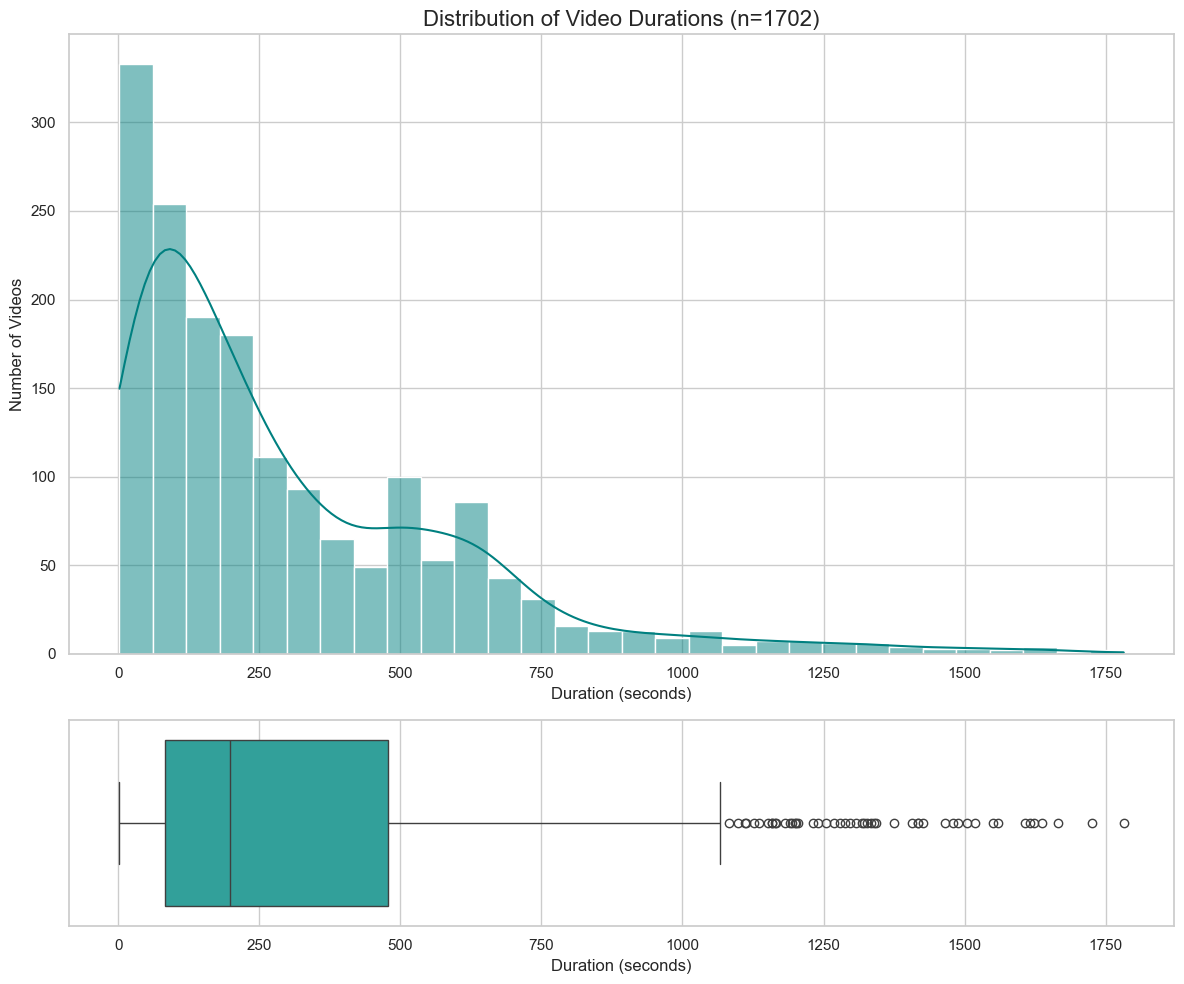


--- Dataset Summary ---
Total Videos: 1702
Total Playtime: 143.82 hours
Average Duration: 304.20s
Shortest: 2.20s | Longest: 1782.17s


In [7]:
plot_video_durations("crawled_downloads")

In [22]:
def plot_video_durations(directory_path):
    durations = []
    file_names = [f for f in os.listdir(directory_path) if f.endswith('.mp4')]
    
    print(f"Analyzing {len(file_names)} videos...")
    
    for filename in tqdm(file_names):
        video_path = os.path.join(directory_path, filename)
        cap = cv2.VideoCapture(video_path)
        
        if cap.isOpened():
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
            if fps > 0:
                duration_seconds = frame_count / fps
                durations.append(duration_seconds)
        cap.release()

    if not durations:
        print("No valid MP4 files found.")
        return

    # Calculate Percentiles
    p5 = np.percentile(durations, 5)
    p95 = np.percentile(durations, 95)
    mean_val = np.mean(durations)

    # Set up the styling
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    # 1. Histogram
    sns.histplot(durations, bins=30, kde=True, ax=ax1, color='teal')
    
    # Add vertical lines for percentiles
    ax1.axvline(p5, color='red', linestyle='--', linewidth=2, label=f'5th Percentile: {p5:.2f}s')
    ax1.axvline(p95, color='orange', linestyle='--', linewidth=2, label=f'95th Percentile: {p95:.2f}s')
    ax1.axvline(mean_val, color='black', linestyle='-', linewidth=1, label=f'Mean: {mean_val:.2f}s')
    
    ax1.legend()
    ax1.set_title(f'Video Duration Distribution (n={len(durations)})', fontsize=16)
    ax1.set_xlabel('Duration (seconds)')

    # 2. Boxplot
    sns.boxplot(x=durations, ax=ax2, color='lightseagreen')
    ax2.set_xlabel('Duration (seconds)')

    plt.tight_layout()
    plt.savefig("duration_analysis.png") # Saves the plot to your folder
    plt.show()

    # Detailed Summary
    print(f"\n" + "="*30)
    print(f"📊 DATASET SUMMARY STATS")
    print(f"="*30)
    print(f"Total Videos:      {len(durations)}")
    print(f"Average Duration:  {mean_val:.2f}s")
    print(f"Median Duration:   {np.median(durations):.2f}s")
    print(f"Shortest Video:    {min(durations):.2f}s")
    print(f"Longest Video:     {max(durations):.2f}s")
    print(f"-"*30)
    print(f"5th Percentile:    {p5:.2f}s  (95% of videos are longer than this)")
    print(f"95th Percentile:   {p95:.2f}s (5% of videos are longer than this)")
    print(f"="*30)

Analyzing 1702 videos...


100%|██████████| 1702/1702 [00:12<00:00, 131.07it/s]


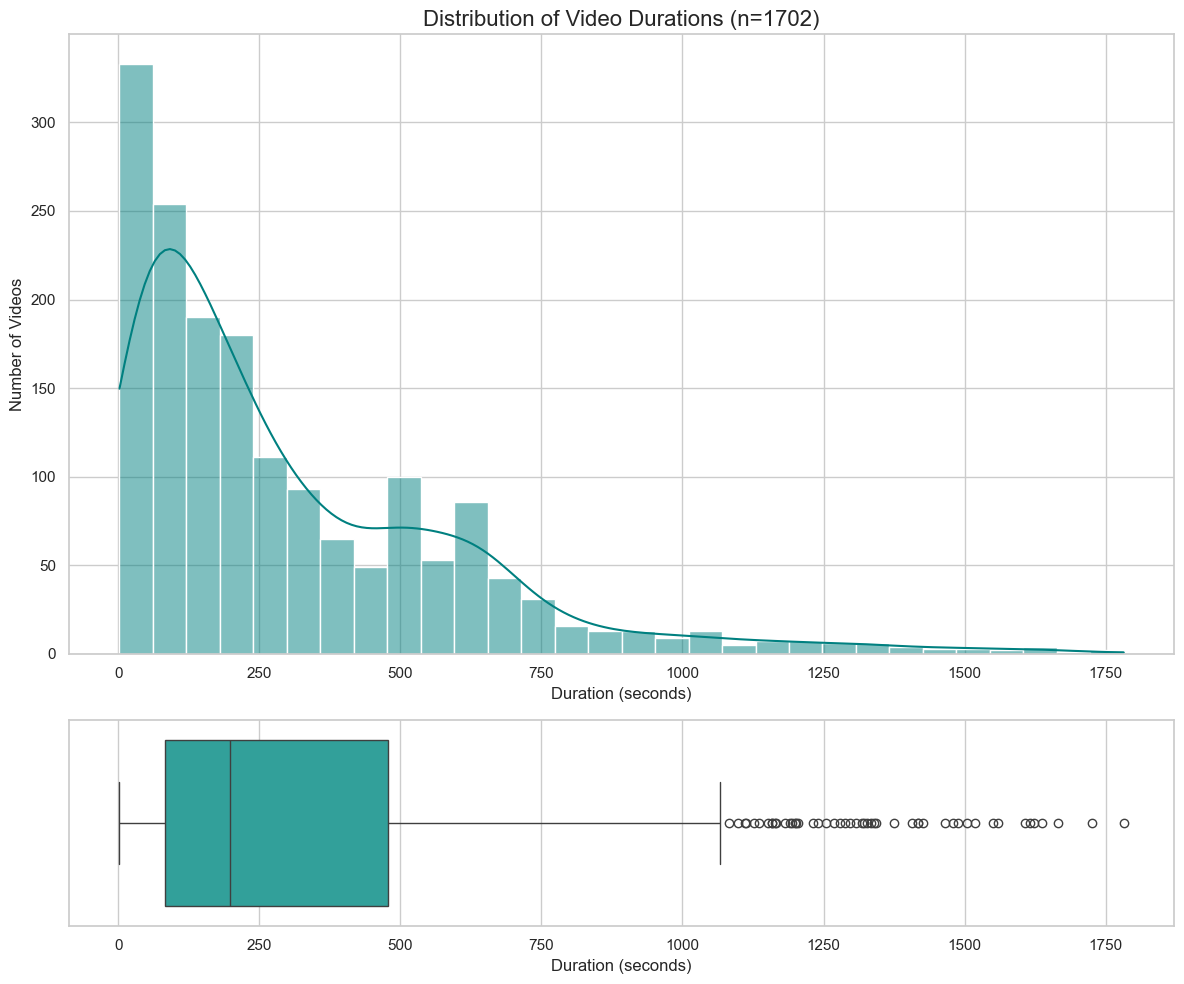


--- Dataset Summary ---
Total Videos: 1702
Total Playtime: 143.82 hours
Average Duration: 304.20s
Shortest: 2.20s | Longest: 1782.17s


In [8]:
plot_video_durations("crawled_downloads")

let's discard all videos longer than 1000 seconds

In [25]:
def plot_filtered_durations(directory_path, max_duration=1000):
    durations = []
    discarded_count = 0
    file_names = [f for f in os.listdir(directory_path) if f.endswith('.mp4')]
    
    print(f"Analyzing {len(file_names)} videos (Discarding > {max_duration}s)...")
    
    for filename in tqdm(file_names):
        video_path = os.path.join(directory_path, filename)
        cap = cv2.VideoCapture(video_path)
        
        if cap.isOpened():
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
            if fps > 0:
                duration_seconds = frame_count / fps
                
                # --- The Filter Logic ---
                if duration_seconds <= max_duration:
                    durations.append(duration_seconds)
                else:
                    discarded_count += 1
        cap.release()

    if not durations:
        print("No videos passed the filter.")
        return []

    # Calculate Stats for the "Passed" videos
    p5 = np.percentile(durations, 5)
    p95 = np.percentile(durations, 95)
    mean_val = np.mean(durations)

    # Visualization
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    # Histogram
    sns.histplot(durations, bins=30, kde=True, ax=ax1, color='teal')
    ax1.axvline(p5, color='red', linestyle='--', label=f'5th Percentile: {p5:.2f}s')
    ax1.axvline(p95, color='orange', linestyle='--', label=f'95th Percentile: {p95:.2f}s')
    ax1.legend()
    ax1.set_title(f'Duration Distribution (Videos <= {max_duration}s)', fontsize=16)

    # Boxplot
    sns.boxplot(x=durations, ax=ax2, color='lightseagreen')
    
    plt.tight_layout()
    plt.show()

    print(f"\n" + "="*40)
    print(f"📊 FILTERED DATASET SUMMARY")
    print(f"="*40)
    print(f"Total Analyzed:   {len(file_names)}")
    print(f"Kept (<=300s):    {len(durations)}")
    print(f"Discarded:        {discarded_count} (Too long)")
    print(f"Discard Rate:     {(discarded_count/len(file_names))*100:.1f}%")
    print(f"-"*40)
    print(f"5th Percentile:   {p5:.2f}s")
    print(f"95th Percentile:  {p95:.2f}s")
    print(f"="*40)

    return durations

Analyzing 2427 videos (Discarding > 300s)...


100%|██████████| 2427/2427 [00:10<00:00, 222.01it/s]


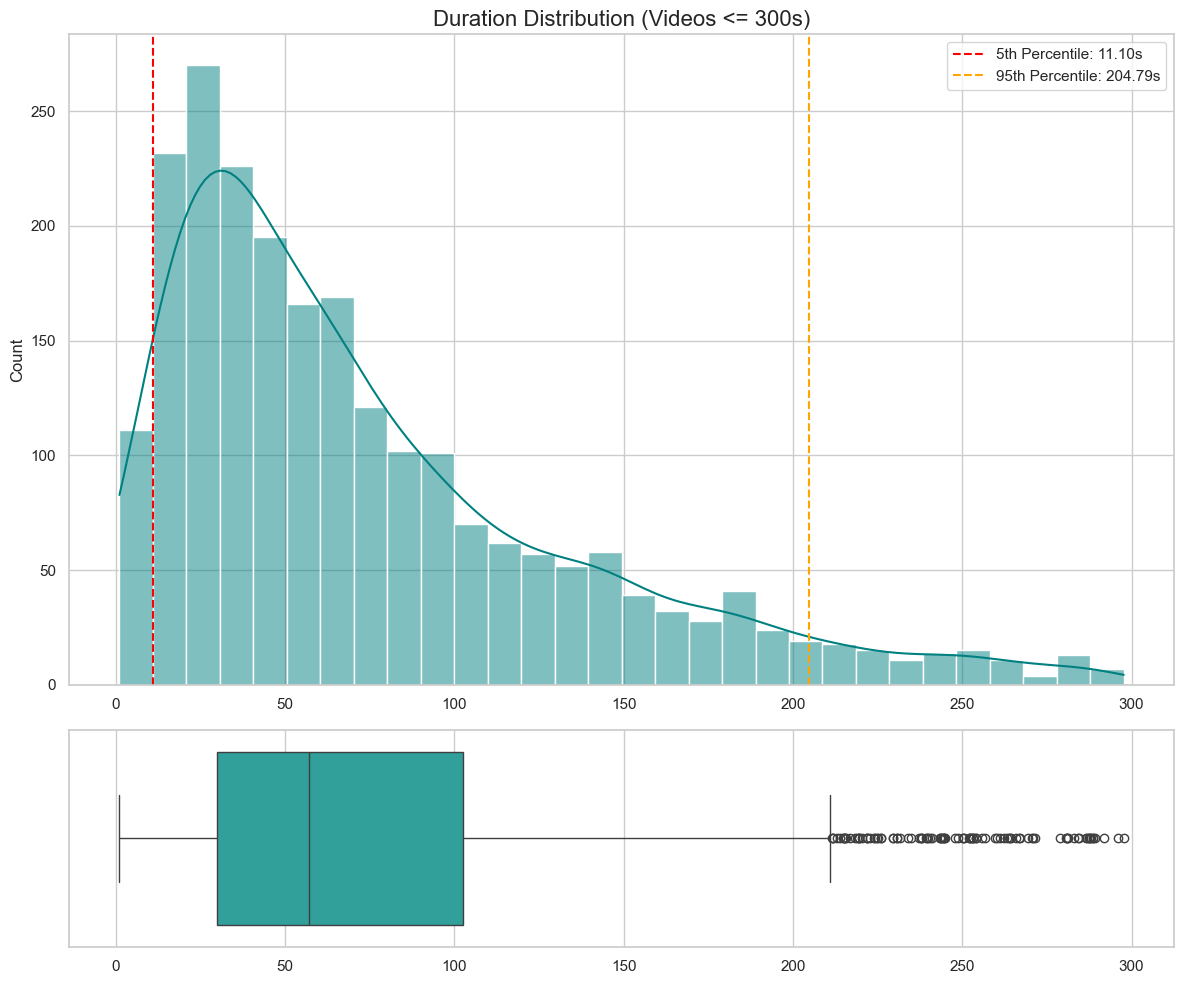


📊 FILTERED DATASET SUMMARY
Total Analyzed:   2427
Kept (<=300s):    2283
Discarded:        144 (Too long)
Discard Rate:     5.9%
----------------------------------------
5th Percentile:   11.10s
95th Percentile:  204.79s


[19.9,
 31.4,
 180.0,
 74.74133333333333,
 52.18546666666667,
 30.266666666666666,
 75.76666666666667,
 28.8,
 58.79206666666667,
 46.541666666666664,
 43.551000202515695,
 38.52,
 3.1698333333333335,
 95.567,
 112.94616666666667,
 35.766666666666666,
 140.76630176106616,
 61.730769230769226,
 22.76,
 18.56,
 16.7,
 13.0,
 29.90435617925907,
 68.4,
 24.949832775919734,
 57.3,
 11.733333333333333,
 56.99026666666667,
 45.233333333333334,
 104.6,
 47.63333333333333,
 23.233333333333334,
 72.1642634062064,
 148.98216666666667,
 59.4,
 22.0,
 141.6415,
 219.0,
 18.733333333333334,
 93.76666666666667,
 47.18046666666667,
 145.0,
 164.43333333333334,
 33.52,
 80.08556721705996,
 78.63333333333334,
 60.72733333333333,
 20.433333333333334,
 17.636097431119392,
 84.8,
 57.333333333333336,
 83.03333333333333,
 131.39793333333333,
 31.566666666666666,
 66.1661,
 72.90616666666666,
 71.53333333333333,
 35.033,
 61.0,
 78.6786,
 7.0,
 130.24,
 141.52,
 11.052708333333333,
 87.16,
 56.63991666666666

In [27]:
plot_filtered_durations("downloads/VideoDataUnbalanced", max_duration=300)

# The pipeline

In [9]:
import os
import cv2
from ultralytics import YOLO
from scenedetect import detect, ContentDetector

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# Settings
MODEL_PATH = "yolo11m.pt"
CAT_CLASS_ID = 15
MIN_SEGMENT_DURATION = 3.0
MAX_VIDEO_DURATION = 300.0
model = YOLO(MODEL_PATH).to("mps")

In [12]:
def process_directory(directory):
    all_results = {}
    files = [f for f in os.listdir(directory) if f.endswith('.mp4')]
    
    for filename in files:
        path = os.path.join(directory, filename)
        
        # Pre-filter duration
        cap = cv2.VideoCapture(path)
        duration = cap.get(cv2.CAP_PROP_FRAME_COUNT) / cap.get(cv2.CAP_PROP_FPS)
        cap.release()
        
        if duration > MAX_VIDEO_DURATION:
            print(f"Skipping {filename}: Too long ({duration:.1f}s)")
            continue
            
        print(f"Processing {filename}...")
        segments = get_single_cat_segments(path)
        if segments:
            all_results[filename] = segments
            
    return all_results

In [107]:
process_directory("downloads/SampleDirectory")

Processing Weird meow from a cat!.mp4...
Processing Adorable Bengal Kitten Purr Meow.mp4...
Processing Drying My Cat Lucky.mp4...


{'Weird meow from a cat!.mp4': [{'scene': 0,
   'start': 0.93,
   'end': 10.29,
   'duration': 9.36},
  {'scene': 2, 'start': 11.59, 'end': 17.9, 'duration': 6.31},
  {'scene': 8, 'start': 30.72, 'end': 39.36, 'duration': 8.64},
  {'scene': 10, 'start': 40.5, 'end': 43.55, 'duration': 3.05},
  {'scene': 17, 'start': 68.58, 'end': 79.45, 'duration': 10.86}],
 'Adorable Bengal Kitten Purr Meow.mp4': [{'scene': 1,
   'start': 10.88,
   'end': 26.86,
   'duration': 15.98}],
 'Drying My Cat Lucky.mp4': [{'scene': 5,
   'start': 37.04,
   'end': 41.98,
   'duration': 4.94}]}

In [13]:
import os
import json
import subprocess
import cv2
from ultralytics import YOLO
from scenedetect import detect, ContentDetector

In [15]:
# --- Configuration ---
OUTPUT_DIR = "crawled_snippets"
METADATA_FILE = "metadata.jsonl"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [16]:
def cut_video_ffmpeg(input_path, output_path, start_time, duration):
    """Cuts a video segment without re-encoding (very fast)."""
    cmd = [
        'ffmpeg', '-y', '-ss', str(start_time), '-t', str(duration),
        '-i', input_path, '-c', 'copy', '-loglevel', 'error', output_path
    ]
    subprocess.run(cmd)

In [17]:
import librosa
import numpy as np
from pydub import AudioSegment

In [18]:
SAMPLE_RATE = 22050
N_MFCC = 20
MAX_MFCC_FRAMES = 174

In [19]:
def extract_features_pydub(audio_segment):
    """
    Витягує MFCCs, Delta, Delta-Delta та Спектральні фічі.
    """
    try:
        # Перетворення частоти дискретизації, моно, 16-bit
        if audio_segment.frame_rate != SAMPLE_RATE:
            audio_segment = audio_segment.set_frame_rate(SAMPLE_RATE)
        if audio_segment.channels > 1:
            audio_segment = audio_segment.set_channels(1)

        audio_array = np.array(audio_segment.get_array_of_samples())
        audio_float = audio_array.astype(np.float32) / (2**15) # Нормалізація

        # 2. Обчислення STFT (Short-Time Fourier Transform)
        # Це потрібно для всіх спектральних фіч
        stft = np.abs(librosa.stft(audio_float))

        # --- ВИЛУЧЕННЯ ФІЧ (LIBROSA) ---

        # A. MFCCs (базові статичні)
        mfccs = librosa.feature.mfcc(y=audio_float, sr=SAMPLE_RATE, n_mfcc=N_MFCC)

        # FIX: Check if we have enough frames for Delta calculation (width=9)
        if mfccs.shape[1] < 9:
            # If too short, we can't compute deltas. 
            # We return None so this snippet is safely discarded.
            return None
        
        # B. Delta та Delta-Delta MFCCs (динамічні)
        mfccs_delta = librosa.feature.delta(mfccs)
        mfccs_delta2 = librosa.feature.delta(mfccs, order=2)

        # C. Спектральні фічі (тембральні)
        # Spectral Centroid (яскравість)
        centroid = librosa.feature.spectral_centroid(S=stft, sr=SAMPLE_RATE)
        # Spectral Flatness (шум vs тон)
        flatness = librosa.feature.spectral_flatness(S=stft)
        # Spectral Roll-off (розподіл енергії)
        rolloff = librosa.feature.spectral_rolloff(S=stft, sr=SAMPLE_RATE)

        # --- 3. ОБ'ЄДНАННЯ ТА УСЕРЕДНЕННЯ (Feature Aggregation) ---

        # 1. Створення єдиного масиву з усіх фреймів
        # Транспонуємо і усереднюємо всі матриці фіч

        # MFCCs та Delta MFCCs
        mfccs_mean = np.mean(mfccs.T, axis=0) # (N_MFCC,)
        mfccs_delta_mean = np.mean(mfccs_delta.T, axis=0) # (N_MFCC,)
        mfccs_delta2_mean = np.mean(mfccs_delta2.T, axis=0) # (N_MFCC,)

        # Спектральні фічі
        centroid_mean = np.mean(centroid.T, axis=0) # (1,)
        flatness_mean = np.mean(flatness.T, axis=0) # (1,)
        rolloff_mean = np.mean(rolloff.T, axis=0) # (1,)

        # 2. Конкатенація всіх усереднених фіч в один вектор
        # Використовуємо np.hstack для об'єднання всіх одновимірних масивів
        all_features = np.hstack([
            mfccs_mean,
            mfccs_delta_mean,
            mfccs_delta2_mean,
            centroid_mean,
            flatness_mean,
            rolloff_mean
        ])

        # Розмір вектора фіч: (N_MFCC * 3) + 3
        # Якщо N_MFCC=20: (20*3) + 3 = 63 фічі!

        return all_features
    except Exception as e:
        print(f"⚠️ ПОМИЛКА ДЕКОДУВАННЯ PYDUB/LIBROSA ({e.__class__.__name__}): {e}")
        return None

In [20]:
import joblib

# Load the model
preclass_model = joblib.load('models/audio_preclassifier/voting_classifier_with-add-data.pkl')

In [21]:
audio_file = "downloads/VideoDataBalanced/Cat Kick Self in Face - Liu Kang Style.mp3.mp3"

In [22]:
CAT_ID = 5

In [82]:
float(preclass_model.predict_proba(features.reshape(1, -1))[0][CAT_ID]) > 0.5

True

In [23]:
def audio_preclassifier(features, prob_threshold: float = 0.5) -> tuple[bool, float]:
    features = features.reshape(1, -1)
    prediction_proba =  float(preclass_model.predict_proba(features)[0][CAT_ID])
    return prediction_proba >= prob_threshold, prediction_proba

# B E H O L D : THE PIPELINE

In [24]:
import os
import json
import subprocess
import numpy as np
import librosa
from pydub import AudioSegment
from tqdm import tqdm
import cv2

In [34]:
# --- Configuration ---
OUTPUT_DIR = "dataset_snippets"
METADATA_FILE = "metadata.jsonl"
SAMPLE_RATE = 16000
N_MFCC = 20

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [26]:
def cut_video_ffmpeg(input_path, output_path, start_time, duration):
    """Cuts the video segment extremely fast without re-encoding."""
    cmd = [
        'ffmpeg', '-y', '-ss', str(start_time), '-t', str(duration),
        '-i', input_path, '-c:v', 'copy', '-an', # '-an' removes audio from video track
        '-loglevel', 'error', output_path
    ]
    subprocess.run(cmd)

In [ ]:
def get_single_cat_segments(video_path):
    """
    Splits video into scenes and finds segments with exactly one stable cat.
    """
    model = YOLO(MODEL_PATH).to("mps")
    
    # 1. Detect Scenes (Camera Cuts)
    scene_list = detect(video_path, ContentDetector())
    # scene_list is a list of tuples: [(start_time, end_time), ...]
    
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    video_segments = []

    # 2. Process Each Scene Independently
    for scene_idx, (start_time, end_time) in enumerate(scene_list):
        start_frame = start_time.get_frames()
        end_frame = end_time.get_frames()
        
        # Dictionary to track cat IDs within THIS scene
        # We reset this every scene to avoid 'ghost' IDs from previous camera angles
        track_history = {} 
        
        # Seek to the start of the scene
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        
        # Run Tracking on the scene segment
        # We use a generator to process frame by frame
        for frame_offset in range(end_frame - start_frame):
            ret, frame = cap.read()
            if not ret: break
            
            results = model.track(
                frame, 
                persist=True, 
                verbose=False, 
                device='mps',
                conf=0.4, 
                classes=[CAT_CLASS_ID]
            )[0]
            
            if results.boxes.id is not None:
                ids = results.boxes.id.int().cpu().tolist()
                
                # Logic: If more than 1 cat is tracked in a frame, we mark this frame as 'multi'
                if len(ids) > 1:
                    # Mark all currently tracked cats in this scene as 'invalid' due to multi-cat interference
                    for tid in ids:
                        if tid not in track_history: track_history[tid] = {'frames': [], 'valid': False}
                        track_history[tid]['valid'] = False
                else:
                    tid = ids[0]
                    if tid not in track_history:
                        track_history[tid] = {'frames': [], 'valid': True}
                    
                    # Only add frames to cats that haven't been disqualified by a multi-cat event
                    if track_history[tid]['valid']:
                        track_history[tid]['frames'].append((start_frame + frame_offset) / fps)

        # 3. Finalize segments for this scene
        for tid, data in track_history.items():
            if data['valid'] and len(data['frames']) > 0:
                seg_start = data['frames'][0]
                seg_end = data['frames'][-1]
                duration = seg_end - seg_start
                
                if duration >= MIN_SEGMENT_DURATION:
                    video_segments.append({
                        "scene": scene_idx,
                        "start": round(seg_start, 2),
                        "end": round(seg_end, 2),
                        "duration": round(duration, 2)
                    })

    cap.release()
    return video_segments

In [28]:
import os
import json
import cv2
import subprocess
import numpy as np
from datetime import datetime
from pydub import AudioSegment
from tqdm.auto import tqdm # Automatically handles notebook vs terminal

In [ ]:
def process_directory(directory):
    video_files = [f for f in os.listdir(directory) if f.endswith('.mp4')]
    print(f"🚀 Found {len(video_files)} potential videos. Starting pipeline...")
    
    with open(METADATA_FILE, 'a') as f_metadata:
        # Outer bar (position 0)
        pbar_outer = tqdm(video_files, desc="Overall Progress", unit="vid", position=0)
        
        for filename in pbar_outer:

            base_name = os.path.splitext(filename)[0].split('_')[0]
            video_path = os.path.join(directory, f"{base_name}_video.mp4")
            audio_path = os.path.join(directory, f"{base_name}_audio.mp3") 
            if not os.path.exists(audio_path):
                print(video_path, audio_path)
                continue 

            # 2. Duration Check
            cap = cv2.VideoCapture(video_path)
            fps = cap.get(cv2.CAP_PROP_FPS)
            duration = cap.get(cv2.CAP_PROP_FRAME_COUNT) / fps if fps > 0 else 0
            cap.release()

            if duration > 300 or duration == 0:
                continue

            # 3. Visual Gate: YOLO Tracking
            raw_segments = get_single_cat_segments(video_path) 
            if not raw_segments:
                continue
                
            try:
                full_audio = AudioSegment.from_file(audio_path)
            except Exception as e:
                print(f"⚠️ Skipping corrupted audio: {audio_path}")
                continue
            
            # 4. Chunking Logic (3 to 7s)
            valid_chunks = []
            for seg in raw_segments:
                curr_start = seg['start']
                seg_end = seg['end']
                while (seg_end - curr_start) >= 3.0:
                    chunk_dur = min(7.0, seg_end - curr_start)
                    valid_chunks.append({'start': curr_start, 'duration': chunk_dur})
                    curr_start += chunk_dur

            if not valid_chunks:
                continue

            # 5. Audio Gate & Stats Tracking
            video_record = {
                "original_video": filename,
                "processed_at": datetime.now().isoformat(), # Added timestamp
                "total_chunks_analyzed": len(valid_chunks),
                "saved_chunks_count": 0,
                "snippets": []
            }

            # Inner Progress Bar (position 1)
            # leave=False ensures it disappears after the video is done
            pbar_inner = tqdm(valid_chunks, desc=f"   🔍 {filename[:15]}...", 
                              leave=False, position=1, unit="chk")
            
            for i, chunk in enumerate(pbar_inner):
                start_ms = int(chunk['start'] * 1000)
                end_ms = int((chunk['start'] + chunk['duration']) * 1000)
                audio_chunk = full_audio[start_ms:end_ms]
                
                features = extract_features_pydub(audio_chunk)
                if features is None:
                    continue
                    
                # Using your classifier
                prediction, proba = audio_preclassifier(features, prob_threshold=0.5)
                
                if prediction == 1:
                    video_record["saved_chunks_count"] += 1
                    snip_base = f"{base_name}_snip_{i}"
                    
                    vid_snip_path = os.path.join(OUTPUT_DIR, f"{snip_base}.mp4")
                    aud_snip_path = os.path.join(OUTPUT_DIR, f"{snip_base}.mp3")
                    
                    # Save files
                    cut_video_ffmpeg(video_path, vid_snip_path, chunk['start'], chunk['duration'])
                    audio_chunk.export(aud_snip_path, format="mp3")
                    
                    video_record["snippets"].append({
                        "id": snip_base,
                        "audio_proba": round(float(proba), 4),
                        "timestamp_range": [round(chunk['start'], 2), round(chunk['start'] + chunk['duration'], 2)],
                        "duration": round(chunk['duration'], 2)
                    })

            # Update the outer bar description with the "hit rate"
            stats = f"Saved {video_record['saved_chunks_count']}/{video_record['total_chunks_analyzed']}"
            pbar_outer.set_postfix_str(f"Last Video: {stats}")

            # 6. Final Log
            if video_record["snippets"]:
                f_metadata.write(json.dumps(video_record) + '\n')
                f_metadata.flush()

    print(f"\n✅ All done! Check {METADATA_FILE} for results.")

In [46]:
process_directory("crawled_downloads")

🚀 Found 1702 potential videos. Starting pipeline...


Overall Progress:   0%|          | 0/1702 [00:00<?, ?vid/s]

WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ n

Overall Progress:   0%|          | 1/1702 [07:10<203:32:31, 430.78s/vid, Last Video: Saved 1/8]

WARNING ⚠️ not enough matching points


...

WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ not enough matching points
WARNING ⚠️ n

Overall Progress:  34%|███▍      | 577/1702 [13:22:11<29:39:35, 94.91s/vid, Last Video: Saved 9/18]  

WARNING ⚠️ not enough matching points


Overall Progress:  36%|███▋      | 618/1702 [14:03:15<18:28:27, 61.35s/vid, Last Video: Saved 2/4]  [h264 @ 0x548738ff0] mmco: unref short failure
[h264 @ 0x548738ff0] mmco: unref short failure
[h264 @ 0x548738ff0] mmco: unref short failure
[h264 @ 0x548738ff0] mmco: unref short failure
Overall Progress:  38%|███▊      | 640/1702 [15:03:37<24:59:26, 84.71s/vid, Last Video: Saved 4/10]  


CouldntDecodeError: Decoding failed. ffmpeg returned error code: 183

Output from ffmpeg/avlib:

ffmpeg version 8.0 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 17.0.0 (clang-1700.0.13.3)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass

In [50]:
if __name__ == "__main__":

    import os
    import json
    import cv2
    from datetime import datetime
    from multiprocessing import Pool, cpu_count
    from tqdm import tqdm
    from pydub import AudioSegment
    from ultralytics import YOLO
    from scenedetect import detect, ContentDetector

    # =========================
    # CONFIG
    # =========================

    MODEL_PATH = "yolo11m.pt"
    CAT_CLASS_ID = 15
    MIN_SEGMENT_DURATION = 3.0
    FRAME_STRIDE = 3

    OUTPUT_DIR = "dataset_snippets"
    METADATA_FILE = "metadata.jsonl"

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # Global model (loaded once per worker)
    model = None

    # =========================
    # WORKER INIT
    # =========================

    def init_worker():
        global model
        model = YOLO(MODEL_PATH).to("mps")

    # =========================
    # HELPER FUNCTIONS
    # =========================

    def load_processed_videos():
        processed = set()
        if not os.path.exists(METADATA_FILE):
            return processed
        with open(METADATA_FILE, "r") as f:
            for line in f:
                try:
                    data = json.loads(line)
                    processed.add(data["original_video"])
                except Exception:
                    continue
        return processed

    def get_single_cat_segments(video_path):
        global model
        scene_list = detect(video_path, ContentDetector())
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        video_segments = []

        for scene_idx, (start_time, end_time) in enumerate(scene_list):
            start_frame = start_time.get_frames()
            end_frame = end_time.get_frames()
            track_history = {}

            model.tracker.reset()  # reset tracker per scene

            for frame_idx in range(start_frame, end_frame, FRAME_STRIDE):
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                ret, frame = cap.read()
                if not ret:
                    break

                results = model.track(
                    frame,
                    persist=True,
                    verbose=False,
                    conf=0.4,
                    classes=[CAT_CLASS_ID]
                )[0]

                if results.boxes.id is None:
                    continue

                ids = results.boxes.id.int().cpu().tolist()

                if len(ids) > 1:
                    for tid in ids:
                        track_history.setdefault(tid, {"frames": [], "valid": False})
                        track_history[tid]["valid"] = False
                else:
                    tid = ids[0]
                    track = track_history.setdefault(tid, {"frames": [], "valid": True})
                    if track["valid"]:
                        track["frames"].append(frame_idx / fps)

            for tid, data in track_history.items():
                if data["valid"] and data["frames"]:
                    seg_start = data["frames"][0]
                    seg_end = data["frames"][-1]
                    duration = seg_end - seg_start
                    if duration >= MIN_SEGMENT_DURATION:
                        video_segments.append({
                            "scene": scene_idx,
                            "start": round(seg_start, 2),
                            "end": round(seg_end, 2),
                            "duration": round(duration, 2)
                        })

        cap.release()
        return video_segments

    # =========================
    # VIDEO PROCESSING
    # =========================

    def process_single_video(args):
        directory, filename = args
        base_name = filename.replace("_video.mp4", "")
        video_path = os.path.join(directory, f"{base_name}_video.mp4")
        audio_path = os.path.join(directory, f"{base_name}_audio.mp3")

        if not os.path.exists(audio_path):
            return None

        # duration check
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        duration = cap.get(cv2.CAP_PROP_FRAME_COUNT) / fps if fps > 0 else 0
        cap.release()
        if duration > 300 or duration == 0:
            return None

        # visual stage
        raw_segments = get_single_cat_segments(video_path)
        if not raw_segments:
            return None

        # audio load
        try:
            full_audio = AudioSegment.from_file(audio_path)
        except Exception:
            print(f"⚠️ Corrupted audio skipped: {audio_path}")
            return None

        # chunking
        valid_chunks = []
        for seg in raw_segments:
            curr_start = seg["start"]
            seg_end = seg["end"]
            while (seg_end - curr_start) >= 3.0:
                chunk_dur = min(7.0, seg_end - curr_start)
                valid_chunks.append({"start": curr_start, "duration": chunk_dur})
                curr_start += chunk_dur

        if not valid_chunks:
            return None

        video_record = {
            "original_video": filename,
            "processed_at": datetime.now().isoformat(),
            "total_chunks_analyzed": len(valid_chunks),
            "saved_chunks_count": 0,
            "snippets": []
        }

        # audio classification stage
        for i, chunk in enumerate(valid_chunks):
            start_ms = int(chunk["start"] * 1000)
            end_ms = int((chunk["start"] + chunk["duration"]) * 1000)
            audio_chunk = full_audio[start_ms:end_ms]

            features = extract_features_pydub(audio_chunk)
            if features is None:
                continue

            prediction, proba = audio_preclassifier(features, prob_threshold=0.5)
            if prediction == 1:
                video_record["saved_chunks_count"] += 1
                snip_base = f"{base_name}_snip_{i}"
                vid_snip_path = os.path.join(OUTPUT_DIR, f"{snip_base}.mp4")
                aud_snip_path = os.path.join(OUTPUT_DIR, f"{snip_base}.mp3")
                cut_video_ffmpeg(video_path, vid_snip_path, chunk["start"], chunk["duration"])
                audio_chunk.export(aud_snip_path, format="mp3")
                video_record["snippets"].append({
                    "id": snip_base,
                    "audio_proba": round(float(proba), 4),
                    "timestamp_range": [
                        round(chunk["start"], 2),
                        round(chunk["start"] + chunk["duration"], 2)
                    ],
                    "duration": round(chunk["duration"], 2)
                })

        if video_record["snippets"]:
            return video_record
        return None

    # =========================
    # PIPELINE ENTRYPOINT
    # =========================

    def process_directory(directory):
        video_files = [f for f in os.listdir(directory) if f.endswith("_video.mp4")]
        processed = load_processed_videos()
        video_files = [v for v in video_files if v not in processed]

        print(f"🚀 Found {len(video_files)} videos to process")
        tasks = [(directory, f) for f in video_files]
        workers = max(cpu_count() - 1, 1)

        with Pool(workers, initializer=init_worker) as pool, open(METADATA_FILE, "a") as f_metadata:
            for result in tqdm(pool.imap_unordered(process_single_video, tasks), total=len(tasks), desc="Overall Progress", unit="video"):
                if result:
                    f_metadata.write(json.dumps(result) + "\n")
                    f_metadata.flush()

        print(f"\n✅ Done. Metadata saved to {METADATA_FILE}")

    # =========================
    # RUN
    # =========================

    process_directory("crawled_downloads")

🚀 Found 1515 videos to process


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'init_worker' on <module '__main__' (built-in)>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reducti

KeyboardInterrupt: 

In [6]:
import os
import json

# =========================
# CONFIG
# =========================
METADATA_FILE = "metadata.jsonl"  # path to your JSONL metadata
VIDEO_DIR = "crawled_downloads"           # folder containing videos and audios
DRY_RUN = False  # Set to False to actually delete files

# =========================
# Load processed videos
# =========================
processed_videos = set()

if os.path.exists(METADATA_FILE):
    with open(METADATA_FILE, "r") as f:
        for line in f:
            try:
                data = json.loads(line)
                processed_videos.add(data["original_video"])
            except Exception:
                continue
else:
    print(f"⚠️ Metadata file not found: {METADATA_FILE}")
    exit(1)

print(f"✅ Found {len(processed_videos)} processed videos in metadata.")

# =========================
# Delete videos and audios
# =========================
deleted_count = 0
for video_file in processed_videos:
    base_name = video_file.replace("_video.mp4", "")
    
    # Construct paths for video and audio
    video_path = os.path.join(VIDEO_DIR, f"{base_name}_video.mp4")
    audio_path = os.path.join(VIDEO_DIR, f"{base_name}_audio.mp3")
    
    for path in [video_path, audio_path]:
        if os.path.exists(path):
            if DRY_RUN:
                print(f"[DRY RUN] Would delete: {path}")
            else:
                try:
                    os.remove(path)
                    deleted_count += 1
                    print(f"Deleted: {path}")
                except Exception as e:
                    print(f"⚠️ Failed to delete {path}: {e}")

if not DRY_RUN:
    print(f"\n✅ Deleted {deleted_count} files (videos + audios).")
else:
    print("\n⚠️ DRY RUN enabled — no files were actually deleted.")

✅ Found 915 processed videos in metadata.
Deleted: crawled_downloads/2oRYH6T0NBE_video.mp4
Deleted: crawled_downloads/2oRYH6T0NBE_audio.mp3
Deleted: crawled_downloads/3kgx2snn30M_video.mp4
Deleted: crawled_downloads/3kgx2snn30M_audio.mp3
Deleted: crawled_downloads/84QUXaayw34_video.mp4
Deleted: crawled_downloads/84QUXaayw34_audio.mp3
Deleted: crawled_downloads/5k9n9ERRfBg_video.mp4
Deleted: crawled_downloads/5k9n9ERRfBg_audio.mp3
Deleted: crawled_downloads/7z9KPTI5ixI_video.mp4
Deleted: crawled_downloads/7z9KPTI5ixI_audio.mp3
Deleted: crawled_downloads/68NBTfZjhAc_video.mp4
Deleted: crawled_downloads/68NBTfZjhAc_audio.mp3
Deleted: crawled_downloads/8xIZnnR93Jc_video.mp4
Deleted: crawled_downloads/8xIZnnR93Jc_audio.mp3
Deleted: crawled_downloads/8BIOwh59SiM_video.mp4
Deleted: crawled_downloads/8BIOwh59SiM_audio.mp3
Deleted: crawled_downloads/1lYEViUrZew_video.mp4
Deleted: crawled_downloads/1lYEViUrZew_audio.mp3
Deleted: crawled_downloads/2A2IgFQpDVg_video.mp4
Deleted: crawled_downloads/